In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

In [ ]:
data = pd.read_csv("uv_data_with_target.csv")  # Replace with your dataset file path


In [ ]:
data

,Month,Day,Hour,Solar_Radiation,Cloud_Cover,Ozone_Level,Altitude,UV_Index,UV_Risk_Level
0,7,16,16,759.764166,0.875883,364.894304,0.241742,0.587353,Low
1,4,4,20,654.386905,0.539095,229.287251,0.441490,1.203476,Low
2,11,11,7,269.222261,0.282472,366.585943,0.893932,1.285757,Low
3,8,24,14,419.846112,0.425228,308.059306,0.269279,1.272356,Low
4,5,23,13,805.412606,0.037571,368.933182,2.732479,6.068712,High
...,...,...,...,...,...,...,...,...,...
995,6,27,9,398.971930,0.752398,263.220262,2.156098,0.526816,Low
996,5,8,1,724.256252,0.531294,211.148171,1.758706,1.404715,Low
997,6,28,10,794.010534,0.677438,321.962552,1.477101,1.577341,Low
998,6,14,9,689.185618,0.428458,248.160763,0.576947,1.723164,Low


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Month            1000 non-null   int64  
 1   Day              1000 non-null   int64  
 2   Hour             1000 non-null   int64  
 3   Solar_Radiation  1000 non-null   float64
 4   Cloud_Cover      1000 non-null   float64
 5   Ozone_Level      1000 non-null   float64
 6   Altitude         1000 non-null   float64
 7   UV_Index         1000 non-null   float64
 8   UV_Risk_Level    1000 non-null   object 
dtypes: float64(5), int64(3), object(1)
memory usage: 70.4+ KB


In [ ]:
data.describe()

,Month,Day,Hour,Solar_Radiation,Cloud_Cover,Ozone_Level,Altitude,UV_Index
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.454000,14.314000,11.426000,547.958736,0.497176,297.613685,1.502595,1.572915
std,3.525665,8.170689,6.924773,260.145029,0.285633,57.635504,0.863333,1.321936
min,1.000000,1.000000,0.000000,100.121224,0.000012,200.006144,0.002830,0.001036
25%,3.000000,7.000000,5.000000,333.832762,0.249504,247.468695,0.772781,0.556376
50%,6.000000,14.000000,11.000000,545.803120,0.500236,296.652636,1.468251,1.222073
75%,10.000000,22.000000,17.000000,778.205276,0.738917,346.338115,2.225567,2.326334
max,12.000000,28.000000,23.000000,998.512760,0.999558,399.549878,2.998051,7.157764


In [ ]:
# Encode categorical target variable

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['UV_Risk_Level'] = label_encoder.fit_transform(data['UV_Risk_Level'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Month            1000 non-null   int64  
 1   Day              1000 non-null   int64  
 2   Hour             1000 non-null   int64  
 3   Solar_Radiation  1000 non-null   float64
 4   Cloud_Cover      1000 non-null   float64
 5   Ozone_Level      1000 non-null   float64
 6   Altitude         1000 non-null   float64
 7   UV_Index         1000 non-null   float64
 8   UV_Risk_Level    1000 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 70.4 KB


In [ ]:
data

,Month,Day,Hour,Solar_Radiation,Cloud_Cover,Ozone_Level,Altitude,UV_Index,UV_Risk_Level
0,7,16,16,759.764166,0.875883,364.894304,0.241742,0.587353,2
1,4,4,20,654.386905,0.539095,229.287251,0.441490,1.203476,2
2,11,11,7,269.222261,0.282472,366.585943,0.893932,1.285757,2
3,8,24,14,419.846112,0.425228,308.059306,0.269279,1.272356,2
4,5,23,13,805.412606,0.037571,368.933182,2.732479,6.068712,1
...,...,...,...,...,...,...,...,...,...
995,6,27,9,398.971930,0.752398,263.220262,2.156098,0.526816,2
996,5,8,1,724.256252,0.531294,211.148171,1.758706,1.404715,2
997,6,28,10,794.010534,0.677438,321.962552,1.477101,1.577341,2
998,6,14,9,689.185618,0.428458,248.160763,0.576947,1.723164,2


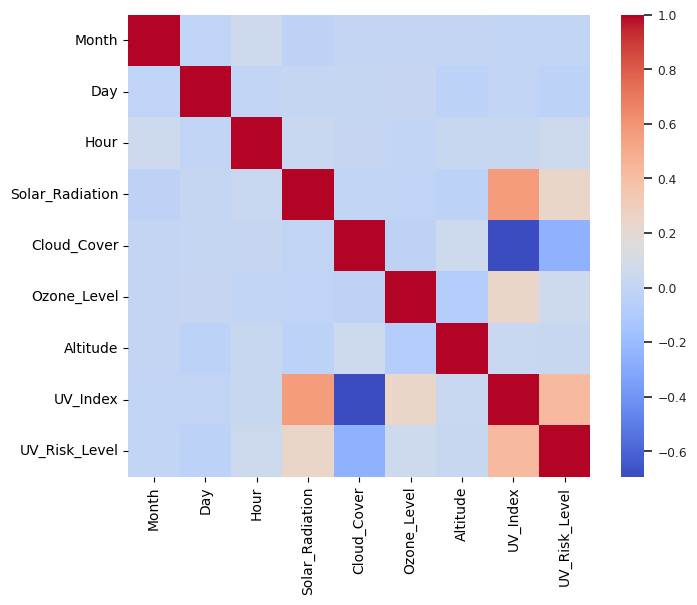

In [ ]:
correlation = data.corr()
plt.subplots(figsize=(8, 6))
sns.set(font_scale=0.8)
sns.heatmap(correlation, square=True,cmap='coolwarm');

In [ ]:
sns.pairplot(data, height = 2.5)
plt.show();

In [ ]:
data['UV_Risk_Level'].unique()


array([2, 1, 3, 0])

In [ ]:
data['UV_Risk_Level'].value_counts()


,count
UV_Risk_Level,
2,846
3,133
0,15
1,6


In [ ]:
data.isnull().sum()


,0
Month,0
Day,0
Hour,0
Solar_Radiation,0
Cloud_Cover,0
Ozone_Level,0
Altitude,0
UV_Index,0
UV_Risk_Level,0


In [ ]:
# Features and target variable
X = data.drop(columns=['UV_Risk_Level'])
y = data['UV_Risk_Level']


In [ ]:
# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

NameError: name 'StandardScaler' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [ ]:
# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Random Forest Classifier
rf_model = RandomForestClassifier(class_weight='balanced',random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [ ]:
# Evaluation
print("Logistic Regression Metrics:")
print(classification_report(y_test, lr_predictions))

print("Random Forest Metrics:")
print(classification_report(y_test, rf_predictions))


In [ ]:
# Compare accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(f"Random Forest Accuracy: {rf_accuracy}")

In [ ]:
lr_model = LogisticRegression(class_weight='balanced')
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)


In [ ]:
report_lr = classification_report(y_test, lr_predictions, output_dict=True)
report_rf = classification_report(y_test, rf_predictions, output_dict=True)

print(report_lr)
print(report_rf)


In [ ]:
# Importing necessary libraries
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
mse = mean_squared_error(y_test, lr_predictions)
mse

In [ ]:
# Importing necessary libraries
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
r2 = r2_score(y_test, lr_predictions)
r2

In [ ]:
# Importing necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sample data
data = {
    'Month': [7, 4, 11, 8, 5],
    'Day': [16, 4, 11, 24, 23],
    'Hour': [16, 20, 7, 14, 13],
    'Solar_Radiation': [759.764166, 654.386905, 269.222261, 419.846112, 805.412606],
    'Cloud_Cover': [0.875883, 0.539095, 0.282472, 0.425228, 0.037571],
    'Ozone_Level': [364.894304, 229.287251, 366.585943, 308.059306, 368.933182],
    'Altitude': [0.241742, 0.441490, 0.893932, 0.269279, 2.732479],
    'UV_Index': [0.587353, 1.203476, 1.285757, 1.272356, 6.068712],
    'UV_Risk_Level': [2, 2, 2, 2, 1]
}

# Creating DataFrame
df = pd.DataFrame(data)

# Scatter plot: Solar Radiation vs UV Risk Level
plt.figure(figsize=(10,6))
sns.scatterplot(x='Solar_Radiation', y='UV_Risk_Level', data=df)
plt.title("Scatter Plot: Solar Radiation vs UV Risk Level")
plt.xlabel("Solar Radiation")
plt.ylabel("UV Risk Level")
plt.show()

# Regression plot: Ozone Level vs UV Risk Level
plt.figure(figsize=(10,6))
sns.regplot(x='Ozone_Level', y='UV_Risk_Level', data=df, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title("Regression Plot: Ozone Level vs UV Risk Level")
plt.xlabel("Ozone Level")
plt.ylabel("UV Risk Level")
plt.show()

# Heatmap for correlation matrix
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title("Heatmap: Correlation Matrix")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample data
data = {
    'Month': [7, 4, 11, 8, 5],
    'Day': [16, 4, 11, 24, 23],
    'Hour': [16, 20, 7, 14, 13],
    'Solar_Radiation': [759.76, 654.39, 269.22, 419.85, 805.41],
    'Cloud_Cover': [0.87, 0.53, 0.28, 0.43, 0.04],
    'Ozone_Level': [364.89, 229.29, 366.59, 308.06, 368.93],
    'Altitude': [0.24, 0.44, 0.89, 0.27, 2.73],
    'UV_Index': [0.59, 1.20, 1.29, 1.27, 6.07],
    'UV_Risk_Level': ['Low', 'Low', 'Low', 'Low', 'High']
}

# Creating DataFrame
df = pd.DataFrame(data)

# Bar Plot: Count of each UV Risk Level
plt.figure(figsize=(8,6))
df['UV_Risk_Level'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of UV Risk Level")
plt.xlabel("UV Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [ ]:
# Line Plot: Solar Radiation over Hours
plt.figure(figsize=(8,6))
plt.plot(df['Hour'], df['Solar_Radiation'], marker='o', color='purple')
plt.title("Solar Radiation Over Hours")
plt.xlabel("Hour")
plt.ylabel("Solar Radiation")
plt.grid(True)
plt.show()


In [ ]:
# Histogram: Distribution of Ozone Levels
plt.figure(figsize=(8,6))
plt.hist(df['Ozone_Level'], bins=5, color='green', edgecolor='black')
plt.title("Distribution of Ozone Levels")
plt.xlabel("Ozone Level")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Scatter Plot: Solar Radiation vs UV Index
plt.figure(figsize=(8,6))
plt.scatter(df['Solar_Radiation'], df['UV_Index'], color='red')
plt.title("Solar Radiation vs UV Index")
plt.xlabel("Solar Radiation")
plt.ylabel("UV Index")
plt.show()


In [ ]:
# Scatter Plot: Solar Radiation vs UV Index
plt.figure(figsize=(8,6))
plt.scatter(df['Solar_Radiation'], df['UV_Index'], color='red')
plt.title("Solar Radiation vs UV Index")
plt.xlabel("Solar Radiation")
plt.ylabel("UV Index")
plt.show()
